In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import tensorflow as tf
import pandas as pd
import os  
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 中文显示配置
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ========== 1. 数据读取与预处理 ==========
csv_file = 'data/time_hourly_statistics.csv'
if not os.path.exists(csv_file):
    raise FileNotFoundError(f"找不到文件：{csv_file}")

# 读取+前向填充（自动检测编码）
try:
    df = pd.read_csv(
        csv_file, 
        encoding='utf-8-sig',  # 优先用带BOM的UTF-8（兼容Excel导出）
        parse_dates=['时间']
    ).fillna(method='ffill').fillna(0)
except UnicodeDecodeError:
    df = pd.read_csv(
        csv_file, 
        encoding='gbk',
        parse_dates=['时间']
    ).fillna(method='ffill').fillna(0)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_40920\431417161.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = pd.read_csv(


In [3]:
# 按时间排序
df = df.sort_values('时间').reset_index(drop=True)
df.shape

(701, 2)

In [4]:
# 提取目标列
target_col = "数量"
if target_col not in df.columns:
    raise ValueError(f"CSV中无'{target_col}'列，列名列表：{df.columns.tolist()}")
data = df[[target_col]].values
print(f"原始数据量：{len(data)} 条")
data.shape

原始数据量：701 条


(701, 1)

In [5]:
# ========== 2. 时序切分（优化步长） ==========
time_steps = 3  # 调整为6步（适配舆情数据的小时级波动）
if len(data) <= time_steps:
    raise ValueError(f"数据量不足！需至少{time_steps+1}条，当前仅{len(data)}条")

In [6]:
def split_sequences(sequences, n_steps):
    """优化的时序切分函数（兼容多维特征）"""
    X, y = [], []
    for i in range(len(sequences) - n_steps):
        X.append(sequences[i:i+n_steps, :])
        y.append(sequences[i+n_steps, 0])  # 仅预测目标列
    return np.array(X), np.array(y)

X 的维度：(样本数, 时间步长, 特征数)
    # 对应结果(698, 3, 1)：
    # 698：切分后的总样本数（原始数据 701 条 - 时间步长 3 = 698）；
    # 3：时间步长（每段输入包含 3 个连续的历史数据）；
    # 1：特征数（这里只取了 “数量” 1 列作为特征）。
核心是split_sequences函数的滑窗切分逻辑：
    以 “原始数据 701 条、时间步长 3” 为例：
    第 1 个样本：X取数据的[0:3, :]（前 3 条），y取第 4 条的目标值；
    第 2 个样本：X取数据的[1:4, :]（第 2-4 条），y取第 5 条的目标值；
    …… 以此类推，直到第 698 个样本：X取[697:700, :]，y取第 701 条的目标值。
    每个X的样本都是 “3 个时间步 × 1 个特征” 的二维数组，将 698 个这样的二维数组合并后，就形成了三维数组(698, 3, 1)。

In [7]:
# 切分数据（保持数据为2D，避免reshape错误）  

X, y = split_sequences(data, time_steps)  
total_samples = X.shape[0]
print(f"时序切分后总样本数：{total_samples}（输入 步长={time_steps}）")
X.shape,y.shape

时序切分后总样本数：698（输入 步长=3）


((698, 3, 1), (698,))

In [8]:
# 划分训练集/测试集（测试集占20%）
train_size = int(total_samples * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"训练集：{X_train.shape} | 测试集：{X_test.shape}")

训练集：(558, 3, 1) | 测试集：(140, 3, 1)


In [9]:
# ========== 3. 数据标准化（修复逻辑） ==========
# 对整个数据的特征进行标准化（而非仅训练集的输入） 
scaler_X = MinMaxScaler(feature_range=(0, 1))
# 展平数据进行缩放（LSTM输入为3D，需先转2D）
X_train_2d = X_train.reshape(-1, time_steps)
X_test_2d = X_test.reshape(-1, time_steps)
X_train_2d.shape,X_test_2d.shape

((558, 3), (140, 3))

In [10]:
X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_2d).reshape(X_test.shape)
X_train_scaled.shape,X_test_scaled.shape

((558, 3, 1), (140, 3, 1))

In [11]:
# 标签标准化
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))
y_train_scaled.shape,y_test_scaled.shape

((558, 1), (140, 1))

tf.keras.Sequential([...])：构建顺序模型
    按 “输入→隐藏层→输出” 的顺序堆叠网络层，是 Keras 中最基础的模型构建方式

tf.keras.layers.LSTM(32, return_sequences=True, input_shape=(time_steps, X_train.shape[2]))：第一层 LSTM 特征提取
    - 32：神经元数量（优化点：比基础模型多，提升拟合能力）；
    - return_sequences=True：返回所有时间步的输出（必须设置，因为下一层还是 LSTM）；
    - input_shape：指定输入维度（time_steps= 时间窗口大小，X_train.shape[2]= 每个时间步的特征数）

tf.keras.layers.Dropout(0.3),  # 优化点：提高Dropout率，强化过拟合抑制
    - 0.3：随机丢弃 30% 的神经元（优化点：比常规 0.2 更高，针对复杂数据强化正则化）；
    - 作用：防止模型过度依赖某几个神经元，提升泛化能力

LSTM(16)：第二层 LSTM 特征提炼
    - 16：神经元数量（少于第一层，逐步压缩特征维度）；
    - 无return_sequences=True：仅返回最后一个时间步的输出（因为后续是全连接层，不需要序列输出）

Dropout(0.2)：轻量正则化
    0.2：丢弃 20% 神经元，平衡特征保留和过拟合（第二层特征更核心，降低 Dropout 率）

Dense(16, activation='relu')：新增全连接层
    - 优化点：基础 LSTM 模型常直接接输出层，这里增加全连接层；
    - 16：神经元数量，relu激活函数：引入非线性，提升模型对复杂规律的拟合能力

Dense(1)：输出层
    - 无激活函数：回归任务（预测连续值，如舆情值）需线性输出；
    - 1：输出维度为 1（预测单个目标值）

In [12]:
model = tf.keras.Sequential([
    # 第一层LSTM：核心时序特征提取（优化点：增加神经元数量）
    tf.keras.layers.LSTM(32, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
    tf.keras.layers.Dropout(0.3),  # 优化点：提高Dropout率，强化过拟合抑制
    tf.keras.layers.LSTM(16),      # 第二层LSTM：进一步提炼高阶时序特征
    tf.keras.layers.Dropout(0.2),  # 轻量Dropout，平衡特征保留与过拟合
    # 新增全连接层：优化点：增加非线性拟合能力
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)       # 输出层：回归任务，无激活函数
])

model.compile(...)：模型编译（训练前的核心配置）
    为模型训练设置 “优化器 + 损失函数 + 评估指标”，是 Keras 模型从 “结构定义” 到 “可训练” 的关键步骤

optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)：
    - 优化器类型：Adam（自适应矩估计），是时序预测任务中最常用的优化器，结合了 SGD 和 RMSprop 的优点，收敛稳定且速度快；
    - 核心调整：learning_rate=0.001（Adam 默认学习率是 0.001，若注释标注 “提高”，说明此前用了更小的值如 0.0001）；
    - 学习率作用：控制模型参数更新的步长 —— 值越大，参数更新越快，收敛可能更快，但过大易震荡不收敛；值越小，收敛越稳但速度慢。

loss='mse'：设置损失
    - mse（均方误差）：回归任务的标配损失函数，计算(真实值-预测值)²的均值，适合连续值预测（如舆情值、股价）；
    - 选择原因：MSE 对异常值敏感，能有效惩罚预测偏差大的样本，符合时序回归的优化目标。

metrics=['mae']：设置训练过程的评估指标
    - mae（平均绝对误差）：计算 `真实值 - 预测值` 的均值，比 MSE 更直观（单位与预测目标一致）；
    - 作用：训练时实时输出 MAE，辅助监控模型效果（仅用于评估，不影响模型优化，优化仍以 MSE 为目标）。

model.summary()：打印模型结构摘要
    - 输出内容：每层的名称、输出形状、参数数量，以及模型总参数数；
    - 核心价值：快速校验模型结构（如 LSTM 神经元数、全连接层维度、输入输出是否符合预期），排查维度错误或结构设计问题。

In [13]:
# 优化器调整（提高学习率）
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # 学习率提高到0.001
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 3, 32)             4352      
                                                                 
 dropout (Dropout)           (None, 3, 32)             0         
                                                                 
 lstm_1 (LSTM)               (None, 16)                3136      
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense (Dense)               (None, 16)                272       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 7,777
Trainable params: 7,777
Non-trainabl

tf.keras.callbacks.EarlyStopping(...)：创建早停回调实例
    回调函数（Callback）是 Keras 中在训练过程的特定阶段（如每轮结束）执行的函数，早停是最常用的防过拟合回调之一

monitor='val_loss'：指定监控指标
    - 监控val_loss（验证集损失，即 MSE），这是早停的核心判断依据；
    - 选择原因：验证集损失能反映模型的泛化能力，若val_loss上升，说明模型开始过拟合；
    - 可选替代：若关注 MAE，也可设为monitor='val_mae'，但回归任务优先监控val_loss。

patience=15（核心调整点）：设置 “容忍轮数”
	- 字面意思：“耐心值”，表示当val_loss连续 15 轮没有下降（变好）时，触发早停；
    - 调整逻辑：注释标注 “允许更多轮次的波动”，说明此前patience更小（如 5/10），增大后给模型更多 “试错空间”—— 避免因验证集损失短期波动（如偶尔上升）而过早停止训练，尤其适合复杂模型（如双层 LSTM）的收敛；
    - 数值意义：patience越大，训练可能越久，但越不容易错过最优模型；越小，停止越快，但可能提前终止（欠拟合）。

restore_best_weights=True：恢复最优权重
    - 核心作用：训练停止时，自动将模型权重恢复到val_loss最低的那一轮（而非最后一轮）；
    - 关键价值：避免因最后几轮val_loss上升导致模型保存 “过拟合权重”，是早停回调最关键的参数（若设为 False，早停的意义大幅降低）。

verbose=1：	打印停止信息
    - verbose=1：当触发早停时，在控制台打印提示（如Epoch 00040: early stopping）；
    - 可选值：0（静默，不打印）、1（打印），设置为 1 便于监控训练过程。

In [14]:
# 早停回调（调整patience）
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,  # 允许更多轮次的波动
    restore_best_weights=True,
    verbose=1
)

In [15]:
# 训练模型
print("\n开始训练模型...")
# - 返回history对象：包含训练过程中每轮的loss、val_loss、mae等指标，用于后续可视化训练曲线；
# - 是 Keras 模型训练的核心方法，负责执行前向传播、反向传播、参数更新。
history = model.fit(
    X_train_scaled, y_train_scaled,     #训练数据（输入 + 标签）
    epochs=200,     #设置最大训练轮数
    batch_size=8,  # 增大batch_size，提升稳定性
    validation_data=(X_test_scaled, y_test_scaled),     #	设置验证集
    callbacks=[early_stop],     #早听回调
    verbose=1       #训练日志打印级别
)


开始训练模型...
Epoch 1/200
70/70 [==============================] - 4s 13ms/step - loss: 0.0091 - mae: 0.0521 - val_loss: 0.0022 - val_mae: 0.0319
Epoch 2/200
70/70 [==============================] - 0s 3ms/step - loss: 0.0067 - mae: 0.0427 - val_loss: 0.0025 - val_mae: 0.0350
Epoch 3/200
70/70 [==============================] - 0s 4ms/step - loss: 0.0065 - mae: 0.0430 - val_loss: 0.0024 - val_mae: 0.0334
Epoch 4/200
70/70 [==============================] - 0s 3ms/step - loss: 0.0063 - mae: 0.0408 - val_loss: 0.0024 - val_mae: 0.0313
Epoch 5/200
70/70 [==============================] - 0s 3ms/step - loss: 0.0062 - mae: 0.0401 - val_loss: 0.0028 - val_mae: 0.0404
Epoch 6/200
70/70 [==============================] - 0s 3ms/step - loss: 0.0062 - mae: 0.0418 - val_loss: 0.0024 - val_mae: 0.0270
Epoch 7/200
70/70 [==============================] - 0s 3ms/step - loss: 0.0061 - mae: 0.0429 - val_loss: 0.0022 - val_mae: 0.0247
Epoch 8/200
70/70 [==============================] - 0s 3ms/step - loss

In [16]:
# ========== 5. 保存模型与损失曲线 ==========
os.makedirs('model', exist_ok=True)     #- exist_ok=True：核心参数 —— 若model文件夹已存在，不报错、不重复创建；若不存在，则创建；
model.save('model/optimized_lstm_model.keras')  # 用新格式保存

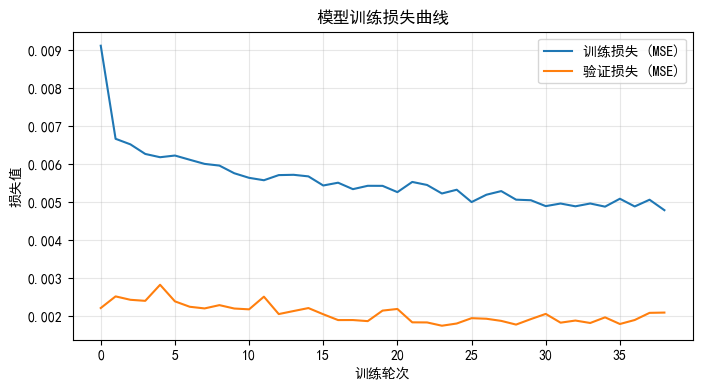

In [17]:
# 绘制损失曲线
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='训练损失 (MSE)')
plt.plot(history.history['val_loss'], label='验证损失 (MSE)')
plt.xlabel('训练轮次')
plt.ylabel('损失值')
plt.title('模型训练损失曲线')
plt.legend()
plt.grid(alpha=0.3)
os.makedirs('figure', exist_ok=True)
plt.savefig('figure/optimized_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

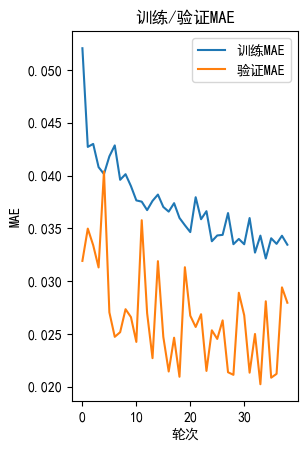

In [18]:
# 绘制MAE指标（若编译时设置了metrics=['mae']）
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='训练MAE')
plt.plot(history.history['val_mae'], label='验证MAE')
plt.title('训练/验证MAE')
plt.xlabel('轮次')
plt.ylabel('MAE')
plt.legend()

In [19]:
# ========== 6. 预测与逆标准化 ==========
y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
y_train_pred_scaled.shape,y_test_pred_scaled.shape

((558, 1), (140, 1))

In [20]:
# 逆标准化
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)
y_train_true = y_train.reshape(-1, 1)
y_test_true = y_test.reshape(-1, 1)
y_train_pred.shape,y_test_pred.shape,y_train_true.shape,y_test_true.shape

((558, 1), (140, 1), (558, 1), (140, 1))

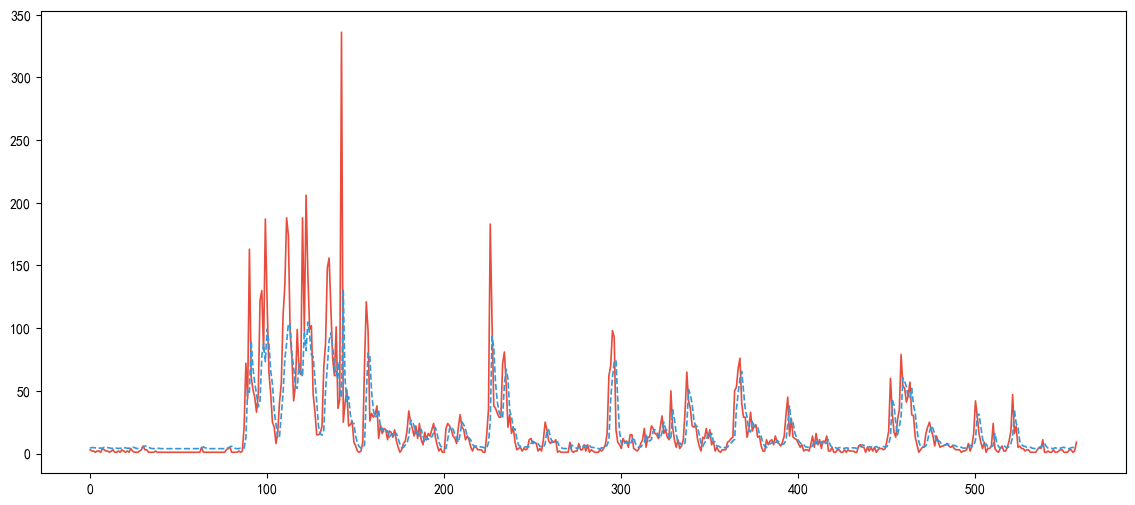

In [21]:
# ========== 7. 优化可视化 ==========
plt.figure(figsize=(14, 6))

# 训练集
plt.plot(range(len(y_train_true)), y_train_true, c='#e74c3c', label='实际值', linewidth=1.2)
plt.plot(range(len(y_train_true)), y_train_pred, c='#3498db', label='预测值', linewidth=1.2, linestyle='--')

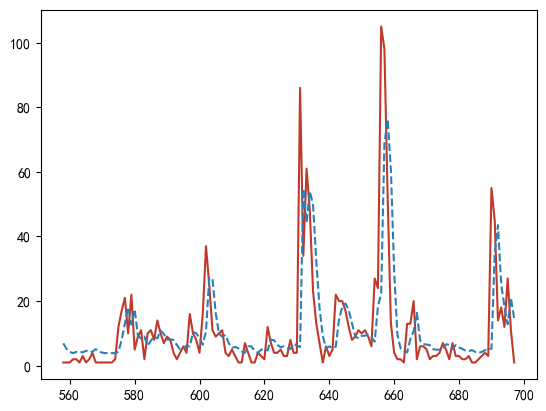

In [22]:
# 测试集
test_start = len(y_train_true)
plt.plot(
    range(test_start, test_start + len(y_test_true)),
    y_test_true,
    c='#c0392b',
    label='测试集实际值',
    linewidth=1.5
)
plt.plot(
    range(test_start, test_start + len(y_test_true)),
    y_test_pred,
    c='#2980b9',
    label='测试集预测值',
    linewidth=1.5,
    linestyle='--'
)

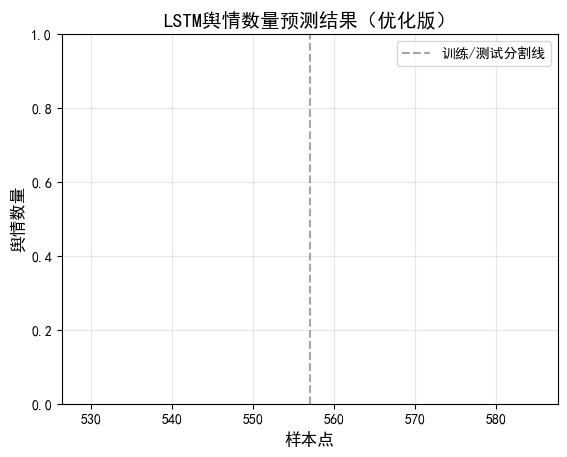

In [23]:
# 分割线
plt.axvline(x=test_start-1, c='gray', linestyle='--', alpha=0.7, label='训练/测试分割线')

plt.xlabel('样本点', fontsize=12)
plt.ylabel('舆情数量', fontsize=12)
plt.title('LSTM舆情数量预测结果（优化版）', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.savefig('figure/optimized_fit_result.png', dpi=500, bbox_inches='tight')
plt.show()

In [24]:
# ========== 8. 完整评估指标 ==========
def eval_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"\n{name}评估指标：")
    print(f"  MAE：{mae:.4f}")
    print(f"  MSE：{mse:.4f}")
    print(f"  RMSE：{rmse:.4f}")
    print(f"  MAPE：{mape:.2f}%")

In [25]:
eval_metrics(y_train_true, y_train_pred, "训练集")
eval_metrics(y_test_true, y_test_pred, "测试集")


训练集评估指标：
  MAE：10.1668
  MSE：550.2153
  RMSE：23.4567
  MAPE：121.77%

测试集评估指标：
  MAE：7.2020
  MSE：195.9117
  RMSE：13.9968
  MAPE：132.43%
